In [1]:
import os
import re
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def extract_job_number(log_path : str) -> int :
    x = log_path.split('_')[0]
    return int(x.strip('output/'))

In [3]:
all_log_files = ['output/' + x for x in os.listdir('output/')]
all_log_files

['output/19374832_output_P_-1_clients_2.log',
 'output/19341918_output.log',
 'output/19374481_output_P_100_clients_2.log',
 'output/19366178_output_f_2000_clients_2.log',
 'output/19374281_output_p_500_clients_2.log',
 'output/19365984_output_f_2000_clients_2.log',
 'output/19360472_output_f_4000_clients_2.log',
 'output/19352478_output_f_4000.log',
 'output/19374304_output_p_250000_clients_2.log',
 'output/19341978_output_f_20.log',
 'output/19363499_output_f_2555_clients_2.log',
 'output/19367671_output_f_17500_clients_100.log',
 'output/19365982_output_f_800_clients_2.log',
 'output/19342006_output.log',
 'output/19365979_output_f_100_clients_2.log',
 'output/19374156_output_f_1000_clients_2.log',
 'output/19374611_output_P_25_clients_2.log',
 'output/19374305_output_p_125000_clients_2.log',
 'output/19374140_output_f_1000_clients_2.log',
 'output/19365977_output_f_1_clients_2.log',
 'output/19331300_output.log',
 'output/19331290_output.log',
 'output/19374306_output_F_1000_client

In [4]:
cut_off = 19374122
log_files = [x for x in all_log_files if extract_job_number(x) >= cut_off]
log_files

['output/19374832_output_P_-1_clients_2.log',
 'output/19374481_output_P_100_clients_2.log',
 'output/19374281_output_p_500_clients_2.log',
 'output/19374304_output_p_250000_clients_2.log',
 'output/19374156_output_f_1000_clients_2.log',
 'output/19374611_output_P_25_clients_2.log',
 'output/19374305_output_p_125000_clients_2.log',
 'output/19374140_output_f_1000_clients_2.log',
 'output/19374306_output_F_1000_clients_2.log',
 'output/19374307_output_F_2000_clients_2.log',
 'output/19374850_output_P_25_clients_2.log',
 'output/19374139_output_f_1000_clients_2.log',
 'output/19374289_output_p_1000000_clients_2.log',
 'output/19374136_output_f_1000_clients_2.log',
 'output/19374843_output_P_-1_clients_2.log',
 'output/19374282_output_p_1000_clients_2.log',
 'output/19374844_output_P_-5_clients_2.log',
 'output/19374283_output_p_5000_clients_2.log',
 'output/19374280_output_p_100_clients_2.log',
 'output/19374846_output_P_-500_clients_2.log',
 'output/19374852_output_P_1_clients_2.log',
 

In [5]:
ps = {
    100 : 'output/19374481_output_P_100_clients_2.log',
    500 : 'output/19374281_output_p_500_clients_2.log',
    250000 : 'output/19374304_output_p_250000_clients_2.log',
    10 :  'output/19374240_output_p_10_clients_2.log',
    125000 : 'output/19374305_output_p_125000_clients_2.log',
    100000 : 'output/19374140_output_f_1000_clients_2.log',
    10000 : 'output/19374284_output_p_10000_clients_2.log',
    1000000 : 'output/19374289_output_p_1000000_clients_2.log',
    1000 : 'output/19374280_output_p_100_clients_2.log',
    5000 : 'output/19374283_output_p_5000_clients_2.log',
    500000 : 'output/19374303_output_p_500000_clients_2.log',
    'No Compensation' : 'output/19374122_output_f_1000_clients_2.log',
    50 : 'output/19374241_output_p_50_clients_2.log',
 }


fs = { # p = 100000
    1000 : 'output/19374306_output_F_1000_clients_2.log',
    2000 : 'output/19374307_output_F_2000_clients_2.log'}


In [6]:
def extract_eval_acc(file_path):
    # Regex to find eval_acc values
    pattern = r"eval_acc=(\d+\.\d+)"
    
    # Open file and read contents
    with open(file_path, 'r') as file:
        log_text = file.read()
    
    # Find all matches in the log text
    matches = re.findall(pattern, log_text)
    
    # Convert matches to float, skipping the first occurrence
    eval_acc_values = [float(acc) for acc in matches[1:]] if len(matches) > 1 else []
    
    return eval_acc_values


In [7]:
accuracies = {}
for p, log_file in ps.items():
    values = extract_eval_acc(log_file)
    accuracies[f'p={p}'] = values
accuracies

{'p=100': [0.099,
  0.111,
  0.111,
  0.117,
  0.117,
  0.114,
  0.114,
  0.111,
  0.111,
  0.113,
  0.113,
  0.111,
  0.111,
  0.114,
  0.114,
  0.116,
  0.116,
  0.116,
  0.116,
  0.116,
  0.116,
  0.113,
  0.113,
  0.116,
  0.116,
  0.115,
  0.115,
  0.116,
  0.116,
  0.115,
  0.115,
  0.123,
  0.123,
  0.123,
  0.123,
  0.129,
  0.129,
  0.125,
  0.125,
  0.133,
  0.133,
  0.129,
  0.129,
  0.135,
  0.135,
  0.136,
  0.136,
  0.152,
  0.152,
  0.157,
  0.157,
  0.177,
  0.177,
  0.177,
  0.177,
  0.176,
  0.176,
  0.181,
  0.181,
  0.194,
  0.194,
  0.191,
  0.191,
  0.194,
  0.194,
  0.204,
  0.204,
  0.214,
  0.214,
  0.218,
  0.218,
  0.213,
  0.213,
  0.218,
  0.218,
  0.219,
  0.219,
  0.224,
  0.224,
  0.232,
  0.232,
  0.227,
  0.227,
  0.223,
  0.223,
  0.23,
  0.23,
  0.239,
  0.239,
  0.235,
  0.235,
  0.234,
  0.234,
  0.235,
  0.235,
  0.234,
  0.234,
  0.245,
  0.245,
  0.247,
  0.247,
  0.252,
  0.252,
  0.26,
  0.26,
  0.266,
  0.266,
  0.256,
  0.256,
  0.261,
  0.2

In [8]:
df = pd.DataFrame.from_dict(accuracies, orient='index')

row_lengths = df.notna().sum(axis=1)

print(row_lengths)

p=100                3747
p=500                1999
p=250000              999
p=10                 1999
p=125000              999
p=100000              999
p=10000              1999
p=1000000             999
p=1000               1999
p=5000               1999
p=500000              999
p=No Compensation     999
p=50                 1999
dtype: int64


In [9]:
df = pd.DataFrame.from_dict(accuracies, orient='index').transpose()
df.dropna(inplace=True)
df

,p=100,p=500,p=250000,p=10,p=125000,p=100000,p=10000,p=1000000,p=1000,p=5000,p=500000,p=No Compensation,p=50
0,0.099,0.099,0.098,0.116,0.100,0.101,0.109,0.104,0.100,0.105,0.099,0.100,0.105
1,0.111,0.116,0.104,0.101,0.099,0.110,0.115,0.110,0.107,0.102,0.110,0.107,0.111
2,0.111,0.116,0.104,0.101,0.099,0.110,0.115,0.110,0.107,0.102,0.110,0.107,0.111
3,0.117,0.124,0.115,0.101,0.099,0.130,0.110,0.109,0.102,0.099,0.113,0.117,0.123
4,0.117,0.124,0.115,0.101,0.099,0.130,0.110,0.109,0.102,0.099,0.113,0.117,0.123
...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,0.487,0.500,0.477,0.101,0.444,0.499,0.492,0.490,0.492,0.482,0.481,0.496,0.497
995,0.490,0.504,0.491,0.101,0.454,0.492,0.496,0.488,0.500,0.474,0.480,0.490,0.497
996,0.490,0.504,0.491,0.101,0.454,0.492,0.496,0.488,0.500,0.474,0.480,0.490,0.497
997,0.487,0.492,0.482,0.101,0.451,0.494,0.501,0.487,0.494,0.474,0.489,0.497,0.487


In [10]:
df.columns

Index(['p=100', 'p=500', 'p=250000', 'p=10', 'p=125000', 'p=100000', 'p=10000',
       'p=1000000', 'p=1000', 'p=5000', 'p=500000', 'p=No Compensation',
       'p=50'],
      dtype='object')

In [11]:
df_filtered = df[['p=No Compensation', 'p=10', 'p=50', 'p=500']]

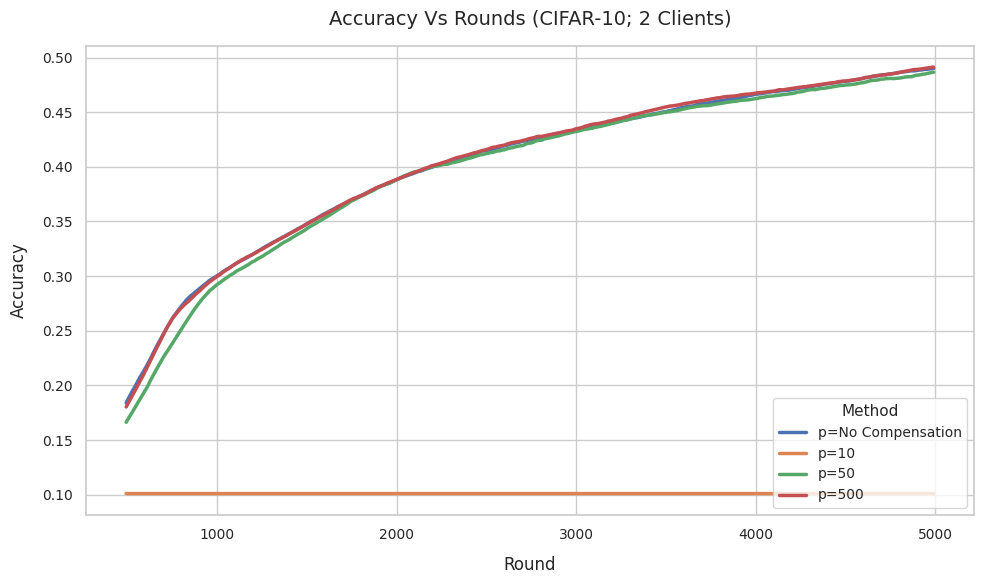

In [13]:
# Calculate the moving average for every 100 rows in the 'value' column
df_long['moving_avg'] = df_long.groupby('q')['value'].transform(lambda x: x.rolling(window=100).mean())

# Drop rows with NaN values that result from the moving average calculation
df_long_filtered = df_long.dropna(subset=['moving_avg'])

# Set the plot style to make it visually appealing
sns.set(style='whitegrid')  # Adds a clean grid background

# Create the line plot using seaborn
plt.figure(figsize=(10, 6))  # Adjust figure size for better presentation
sns.lineplot(data=df_long_filtered, x='index', y='moving_avg', hue='q', linewidth=2.5)

# Add labels and a title
plt.xlabel('Round', fontsize=12, labelpad=10)
plt.ylabel('Accuracy', fontsize=12, labelpad=10)
plt.title('Accuracy Vs Rounds (CIFAR-10; 2 Clients)', fontsize=14, pad=15)

# Customize the ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Add a legend
plt.legend(title='Method', fontsize=10, title_fontsize=11, loc='lower right')

# Show the plot
plt.tight_layout()
plt.show()


In [22]:
ps = {
    100 : 'output/19374481_output_P_100_clients_2.log',
    500 : 'output/19374281_output_p_500_clients_2.log',
    250000 : 'output/19374304_output_p_250000_clients_2.log',
    10 :  'output/19374240_output_p_10_clients_2.log',
    125000 : 'output/19374305_output_p_125000_clients_2.log',
    100000 : 'output/19374140_output_f_1000_clients_2.log',
    10000 : 'output/19374284_output_p_10000_clients_2.log',
    1000000 : 'output/19374289_output_p_1000000_clients_2.log',
    1000 : 'output/19374280_output_p_100_clients_2.log',
    5000 : 'output/19374283_output_p_5000_clients_2.log',
    500000 : 'output/19374303_output_p_500000_clients_2.log',
    'No Compensation' : 'output/19366179_output_f_4000_clients_2.log',
    50 : 'output/19374241_output_p_50_clients_2.log',
    -1 : 'output/19374843_output_P_-1_clients_2.log',
    -5 : 'output/19374844_output_P_-5_clients_2.log',
    -100 : 'output/19374845_output_P_-100_clients_2.log',
    -500 : 'output/19374846_output_P_-500_clients_2.log',
 }

In [23]:
accuracies = {}
for p, log_file in ps.items():
    values = extract_eval_acc(log_file)
    accuracies[f'p={p}'] = values
accuracies

{'p=100': [0.099,
  0.111,
  0.111,
  0.117,
  0.117,
  0.114,
  0.114,
  0.111,
  0.111,
  0.113,
  0.113,
  0.111,
  0.111,
  0.114,
  0.114,
  0.116,
  0.116,
  0.116,
  0.116,
  0.116,
  0.116,
  0.113,
  0.113,
  0.116,
  0.116,
  0.115,
  0.115,
  0.116,
  0.116,
  0.115,
  0.115,
  0.123,
  0.123,
  0.123,
  0.123,
  0.129,
  0.129,
  0.125,
  0.125,
  0.133,
  0.133,
  0.129,
  0.129,
  0.135,
  0.135,
  0.136,
  0.136,
  0.152,
  0.152,
  0.157,
  0.157,
  0.177,
  0.177,
  0.177,
  0.177,
  0.176,
  0.176,
  0.181,
  0.181,
  0.194,
  0.194,
  0.191,
  0.191,
  0.194,
  0.194,
  0.204,
  0.204,
  0.214,
  0.214,
  0.218,
  0.218,
  0.213,
  0.213,
  0.218,
  0.218,
  0.219,
  0.219,
  0.224,
  0.224,
  0.232,
  0.232,
  0.227,
  0.227,
  0.223,
  0.223,
  0.23,
  0.23,
  0.239,
  0.239,
  0.235,
  0.235,
  0.234,
  0.234,
  0.235,
  0.235,
  0.234,
  0.234,
  0.245,
  0.245,
  0.247,
  0.247,
  0.252,
  0.252,
  0.26,
  0.26,
  0.266,
  0.266,
  0.256,
  0.256,
  0.261,
  0.2

In [24]:
df = pd.DataFrame.from_dict(accuracies, orient='index').transpose()
df

,p=100,p=500,p=250000,p=10,p=125000,p=100000,p=10000,p=1000000,p=1000,p=5000,p=500000,p=No Compensation,p=50,p=-1,p=-5,p=-100,p=-500
0,0.099,0.099,0.098,0.116,0.100,0.101,0.109,0.104,0.100,0.105,0.099,0.100,0.105,0.101,0.101,0.098,0.106
1,0.111,0.116,0.104,0.101,0.099,0.110,0.115,0.110,0.107,0.102,0.110,0.104,0.111,0.101,0.101,0.107,0.104
2,0.111,0.116,0.104,0.101,0.099,0.110,0.115,0.110,0.107,0.102,0.110,0.104,0.111,0.101,0.101,0.107,0.104
3,0.117,0.124,0.115,0.101,0.099,0.130,0.110,0.109,0.102,0.099,0.113,0.109,0.123,0.101,0.101,0.115,0.105
4,0.117,0.124,0.115,0.101,0.099,0.130,0.110,0.109,0.102,0.099,0.113,0.109,0.123,0.101,0.101,0.115,0.105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.101,0.101,0.101,0.374
19995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.101,0.101,0.101,0.396
19996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.101,0.101,0.101,0.396
19997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.101,0.101,0.101,0.391


In [25]:
row_lengths = df.notna().sum()
print(row_lengths)

p=100                 3747
p=500                 1999
p=250000               999
p=10                  1999
p=125000               999
p=100000               999
p=10000               1999
p=1000000              999
p=1000                1999
p=5000                1999
p=500000               999
p=No Compensation     9999
p=50                  1999
p=-1                 19999
p=-5                 19999
p=-100               19999
p=-500               19999
dtype: int64


In [26]:
df = pd.DataFrame.from_dict(accuracies, orient='index').transpose()

valid_cols = df.columns[df.notna().sum() >= 1999]

# Select the valid columns and truncate to 1999 rows
df_filtered = df[valid_cols].iloc[:1999, :]

# Print or inspect the resulting DataFrame
df_filtered

,p=100,p=500,p=10,p=10000,p=1000,p=5000,p=No Compensation,p=50,p=-1,p=-5,p=-100,p=-500
0,0.099,0.099,0.116,0.109,0.100,0.105,0.100,0.105,0.101,0.101,0.098,0.106
1,0.111,0.116,0.101,0.115,0.107,0.102,0.104,0.111,0.101,0.101,0.107,0.104
2,0.111,0.116,0.101,0.115,0.107,0.102,0.104,0.111,0.101,0.101,0.107,0.104
3,0.117,0.124,0.101,0.110,0.102,0.099,0.109,0.123,0.101,0.101,0.115,0.105
4,0.117,0.124,0.101,0.110,0.102,0.099,0.109,0.123,0.101,0.101,0.115,0.105
...,...,...,...,...,...,...,...,...,...,...,...,...
1994,0.545,0.578,0.101,0.587,0.562,0.551,0.592,0.569,0.101,0.101,0.540,0.536
1995,0.540,0.578,0.101,0.578,0.577,0.551,0.592,0.567,0.101,0.101,0.530,0.536
1996,0.540,0.578,0.101,0.578,0.577,0.551,0.592,0.567,0.101,0.101,0.530,0.536
1997,0.533,0.571,0.101,0.577,0.570,0.562,0.597,0.573,0.101,0.101,0.542,0.542


In [27]:
df_filtered.dropna(inplace=True)
df_filtered

,p=100,p=500,p=10,p=10000,p=1000,p=5000,p=No Compensation,p=50,p=-1,p=-5,p=-100,p=-500
0,0.099,0.099,0.116,0.109,0.100,0.105,0.100,0.105,0.101,0.101,0.098,0.106
1,0.111,0.116,0.101,0.115,0.107,0.102,0.104,0.111,0.101,0.101,0.107,0.104
2,0.111,0.116,0.101,0.115,0.107,0.102,0.104,0.111,0.101,0.101,0.107,0.104
3,0.117,0.124,0.101,0.110,0.102,0.099,0.109,0.123,0.101,0.101,0.115,0.105
4,0.117,0.124,0.101,0.110,0.102,0.099,0.109,0.123,0.101,0.101,0.115,0.105
...,...,...,...,...,...,...,...,...,...,...,...,...
1994,0.545,0.578,0.101,0.587,0.562,0.551,0.592,0.569,0.101,0.101,0.540,0.536
1995,0.540,0.578,0.101,0.578,0.577,0.551,0.592,0.567,0.101,0.101,0.530,0.536
1996,0.540,0.578,0.101,0.578,0.577,0.551,0.592,0.567,0.101,0.101,0.530,0.536
1997,0.533,0.571,0.101,0.577,0.570,0.562,0.597,0.573,0.101,0.101,0.542,0.542


In [32]:
df_filtered3 = df_filtered[['p=No Compensation', 'p=10', 'p=50', 'p=100', 'p=500']]

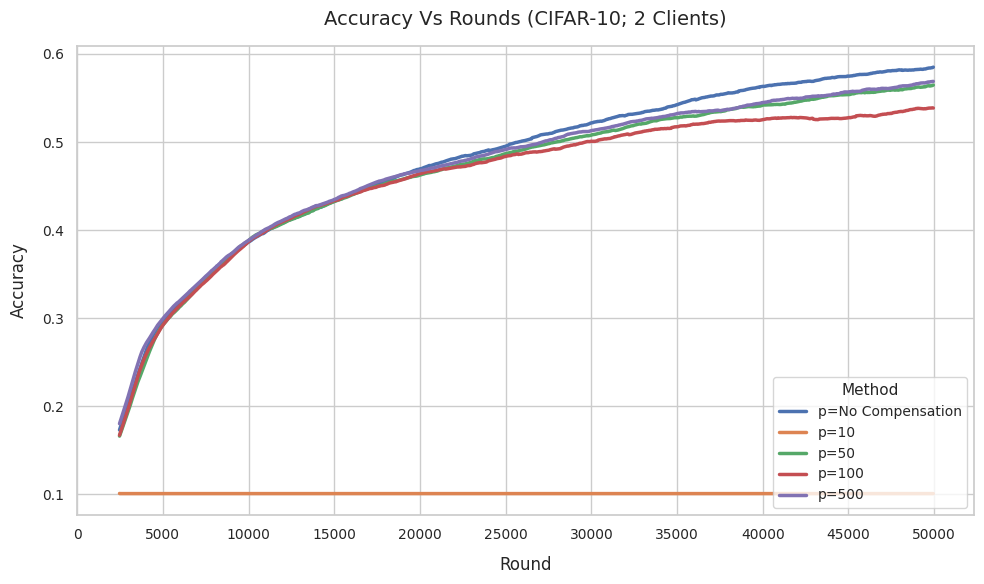

In [33]:
import numpy as np

# Convert the DataFrame into long format
df_long = df_filtered3.reset_index().melt(id_vars='index', var_name='q', value_name='value')

# Multiply the 'index' values by 25 to expand the x-axis range
df_long['index'] = df_long['index'] * 25

# Calculate the moving average for every 100 rows in the 'value' column
df_long['moving_avg'] = df_long.groupby('q')['value'].transform(lambda x: x.rolling(window=100).mean())

# Drop rows with NaN values that result from the moving average calculation
df_long_filtered = df_long.dropna(subset=['moving_avg'])

# Set the plot style to make it visually appealing
sns.set(style='whitegrid')  # Adds a clean grid background

# Create the line plot using seaborn
plt.figure(figsize=(10, 6))  # Adjust figure size for better presentation
sns.lineplot(data=df_long_filtered, x='index', y='moving_avg', hue='q', linewidth=2.5)

# Add labels and a title
plt.xlabel('Round', fontsize=12, labelpad=10)
plt.ylabel('Accuracy', fontsize=12, labelpad=10)
plt.title('Accuracy Vs Rounds (CIFAR-10; 2 Clients)', fontsize=14, pad=15)

# Customize the ticks on the x-axis to be multiples of 5000, from 0 to 50000
plt.xticks(np.arange(0, 50001, step=5000), fontsize=10)  # Set ticks at intervals of 5000

# Customize the y-axis ticks
plt.yticks(fontsize=10)

# Add a legend
plt.legend(title='Method', fontsize=10, title_fontsize=11, loc='lower right')

# Show the plot
plt.tight_layout()
plt.show()


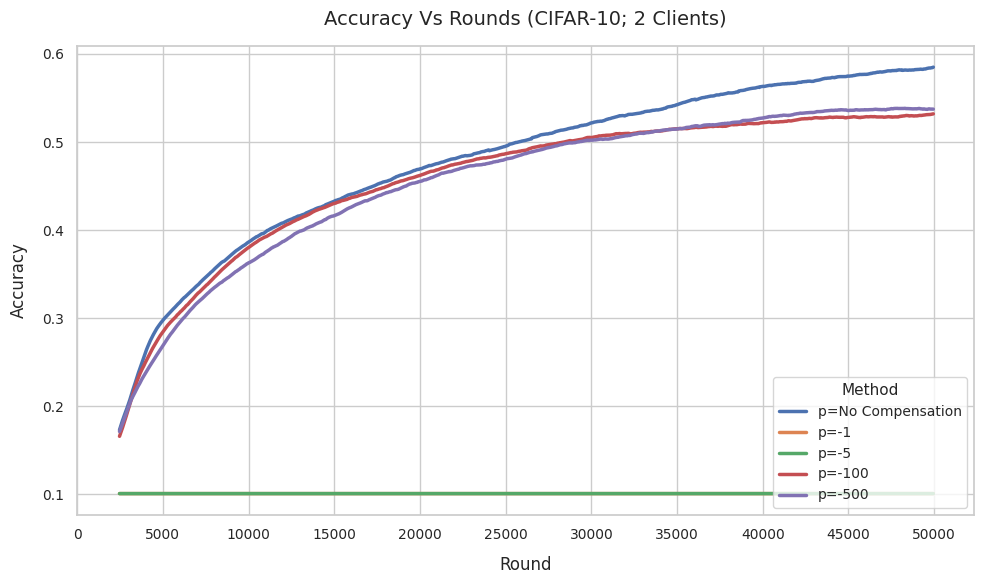

In [37]:
df_filtered4 = df_filtered[['p=No Compensation', 'p=-1', 'p=-5', 'p=-100', 'p=-500']]

import numpy as np

# Convert the DataFrame into long format
df_long = df_filtered4.reset_index().melt(id_vars='index', var_name='q', value_name='value')

# Multiply the 'index' values by 25 to expand the x-axis range
df_long['index'] = df_long['index'] * 25

# Calculate the moving average for every 100 rows in the 'value' column
df_long['moving_avg'] = df_long.groupby('q')['value'].transform(lambda x: x.rolling(window=100).mean())

# Drop rows with NaN values that result from the moving average calculation
df_long_filtered = df_long.dropna(subset=['moving_avg'])

# Set the plot style to make it visually appealing
sns.set(style='whitegrid')  # Adds a clean grid background

# Create the line plot using seaborn
plt.figure(figsize=(10, 6))  # Adjust figure size for better presentation
sns.lineplot(data=df_long_filtered, x='index', y='moving_avg', hue='q', linewidth=2.5)

# Add labels and a title
plt.xlabel('Round', fontsize=12, labelpad=10)
plt.ylabel('Accuracy', fontsize=12, labelpad=10)
plt.title('Accuracy Vs Rounds (CIFAR-10; 2 Clients)', fontsize=14, pad=15)

# Customize the ticks on the x-axis to be multiples of 5000, from 0 to 50000
plt.xticks(np.arange(0, 50001, step=5000), fontsize=10)  # Set ticks at intervals of 5000

# Customize the y-axis ticks
plt.yticks(fontsize=10)

# Add a legend
plt.legend(title='Method', fontsize=10, title_fontsize=11, loc='lower right')

# Show the plot
plt.tight_layout()
plt.show()
